#### **Problem Statement**

Co's 2014-2018 sales data to identify key revenue and profit drivers across products,channels and regions, Uncover seasonal trends and outliers and align performance against budgets. Use these insights to optimize pricing,promotions and market expanion for sustainable growth and reduce concentration risk.[link text](https://)

In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sheets = pd.read_excel('Regional Sales Dataset.xlsx',sheet_name=None)

In [ ]:
# Assign dataframes to each sheet

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_budgets = sheets['2017 Budgets']
df_state_regg = sheets['State Regions']

In [ ]:
df_sales.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [ ]:
print("df_sales shape " ,(df_sales.shape))
print("df_customers shape ", (df_customers.shape))
print("df_budgets shape ", (df_budgets.shape))
print("df_products shape " ,(df_products.shape))
print("df_regions shape " ,(df_regions.shape))
print("df_state_regg shape " ,(df_state_regg.shape))

df_sales shape  (64104, 12)
df_customers shape  (175, 2)
df_budgets shape  (30, 2)
df_products shape  (30, 2)
df_regions shape  (994, 15)
df_state_regg shape  (49, 3)


In [ ]:
df_state_regg.head(5)

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [ ]:
new_header = df_state_regg.iloc[0]
df_state_regg.columns = new_header
df_state_regg = df_state_regg[1:].reset_index(drop=True)

df_state_regg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [ ]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [ ]:
df_state_regg.isnull().sum()

,0
0,
State Code,0
State,0
Region,0


In [ ]:
df_customers.isnull().sum()

,0
Customer Index,0
Customer Names,0


In [ ]:
df_regions.isnull().sum()

,0
id,0
name,0
county,0
state_code,0
state,0
type,0
latitude,0
longitude,0
area_code,0
population,0


In [ ]:
df_state_regg.isnull().sum()

,0
0,
State Code,0
State,0
Region,0


In [ ]:
df_products.isnull().sum()

,0
Index,0
Product Name,0


In [ ]:
df_budgets.isnull().sum()

,0
Product Name,0
2017 Budgets,0


#### **Data Cleaning and Wrangling**

In [ ]:
df_customers.head(1)

,Customer Index,Customer Names
0,1,Geiss Company


In [ ]:
# Merge with Customers

df = df_sales.merge(
    df_customers,
    how='left',
    left_on= 'Customer Name Index',
    right_on= 'Customer Index'
)

In [ ]:
df_products.head(1)

,Index,Product Name
0,1,Product 1


In [ ]:
# Merge with Products

df = df.merge(
    df_products,
    how ='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [ ]:
df_regions.head(5)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [ ]:
#merge wuth Regions

df = df.merge(
    df_regions,
    how= 'left',
    left_on='Delivery Region Index',
    right_on='id'
)

In [ ]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [ ]:
# Merge with State Region

df = df.merge(
    df_state_regg[['State Code','Region']],
    how= 'left',
    left_on='state_code',
    right_on='State Code'
)

In [ ]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [ ]:
# merge with budgets

df = df.merge(
    df_budgets,
    how='left',
    on='Product Name'
)

In [ ]:
df.to_csv('Regional Sales.csv')

In [ ]:
# Customer Index
# Index
# id
# State Code
# cleanup redundant columns

cols_to_drop = ['Customer Index', 'Index','id', 'State Code']
df = df.drop(columns = cols_to_drop,errors='ignore')

df.head(5)



,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [ ]:
# convert all columns to lowercase for consistency and easier access
df.columns = df.columns.str.lower()
df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [ ]:
# filter columns according to our needs

cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'unit price',
    'order quantity',
    'line total',
    'total unit cost',
    'product name',
    'state_code',
    'state',
    'latitude',
    'longitude',
    'county',
    '2017 budgets'
]

In [ ]:
df = df[cols_to_keep]

In [ ]:
df.head(1)

,ordernumber,orderdate,customer names,channel,unit price,order quantity,line total,total unit cost,product name,state_code,state,latitude,longitude,county,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,2499.1,6,14994.6,1824.343,Product 27,GA,Georgia,32.08354,-81.09983,Chatham County,964940.231


In [ ]:
df = df.rename(columns={
    'ordernumber' : 'order_number',
    'orderdate' : 'order_date',
    'customer names' : 'customer_name',
    'unit price' : 'unit_price',
    'order quantity' : 'order_quantity',
    'line total' : 'revenue',
    'total unit cost' : 'cost',
    'product name' : 'product_name',
    'state_code' : 'state',
    'state' : 'state_name',
    'latitude' : 'lat',
    'longitude' : 'lon',
    '2017 budgets' : 'budget'
})

df.head(1)

,order_number,order_date,customer_name,channel,unit_price,order_quantity,revenue,cost,product_name,state,state_name,lat,lon,county,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,2499.1,6,14994.6,1824.343,Product 27,GA,Georgia,32.08354,-81.09983,Chatham County,964940.231


In [ ]:
# blank out budgets for non-2017 orders

df.loc[df['order_date'].dt.year!=2017,'budget'] = pd.NA

# line total is revenue

df[['order_date','product_name','revenue','budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [ ]:
# line total is revenue

df[['order_date','product_name','revenue','budget']].tail(5)

,order_date,product_name,revenue,budget
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN
64103,2018-02-28,Product 15,7986.4,NaN


In [ ]:
df

,order_number,order_date,customer_name,channel,unit_price,order_quantity,revenue,cost,product_name,state,state_name,lat,lon,county,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,2499.1,6,14994.6,1824.343,Product 27,GA,Georgia,32.08354,-81.09983,Chatham County,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,2351.7,11,25868.7,1269.918,Product 20,IN,Indiana,39.61366,-86.10665,Johnson County,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,978.2,6,5869.2,684.740,Product 26,CA,California,37.66243,-121.87468,Alameda County,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,2338.3,7,16368.1,1028.852,Product 7,IN,Indiana,39.16533,-86.52639,Monroe County,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,2291.4,8,18331.2,1260.270,Product 8,CT,Connecticut,41.77524,-72.52443,Hartford County,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,1815.7,12,21788.4,980.478,Product 26,PA,Pennsylvania,40.15511,-74.82877,Bucks County,NaN
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,864.3,6,5185.8,579.081,Product 21,IL,Illinois,42.11030,-88.03424,Cook County,NaN
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,3953.0,11,43483.0,2648.510,Product 13,FL,Florida,26.24453,-80.20644,Broward County,NaN
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,3959.7,7,27717.9,2930.178,Product 20,NY,New York,42.91002,-78.74182,Erie County,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  object        
 1   order_date      64104 non-null  datetime64[ns]
 2   customer_name   64104 non-null  object        
 3   channel         64104 non-null  object        
 4   unit_price      64104 non-null  float64       
 5   order_quantity  64104 non-null  int64         
 6   revenue         64104 non-null  float64       
 7   cost            64104 non-null  float64       
 8   product_name    64104 non-null  object        
 9   state           64104 non-null  object        
 10  state_name      64104 non-null  object        
 11  lat             64104 non-null  float64       
 12  lon             64104 non-null  float64       
 13  county          64104 non-null  object        
 14  budget          15263 non-null  float64       
dtypes:

In [ ]:
# filter dataset to include only records from 2017
df_2017 = df[df['order_date'].dt.year == 2017]

In [ ]:
df.isnull().sum()

,0
order_number,0
order_date,0
customer_name,0
channel,0
unit_price,0
order_quantity,0
revenue,0
cost,0
product_name,0
state,0


In [ ]:
df_2017.head(5)

,order_number,order_date,customer_name,channel,unit_price,order_quantity,revenue,cost,product_name,state,state_name,lat,lon,county,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,1239.5,6,7437.0,1028.785,Product 30,NJ,New Jersey,40.77955,-74.02375,Hudson County,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,1829.1,5,9145.5,1207.206,Product 13,CO,Colorado,39.06387,-108.55065,Mesa County,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,2412.0,9,21708.0,1664.280,Product 15,CA,California,33.96168,-118.35313,Los Angeles County,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,904.5,8,7236.0,750.735,Product 8,IA,Iowa,42.50056,-90.66457,Dubuque County,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,1112.2,12,13346.4,811.906,Product 2,FL,Florida,28.47689,-82.52546,Hernando County,3050087.565


#### Feature Engineering

In [ ]:
df.head(5)

,order_number,order_date,customer_name,channel,unit_price,order_quantity,revenue,cost,product_name,state,state_name,lat,lon,county,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,2499.1,6,14994.6,1824.343,Product 27,GA,Georgia,32.08354,-81.09983,Chatham County,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,2351.7,11,25868.7,1269.918,Product 20,IN,Indiana,39.61366,-86.10665,Johnson County,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,978.2,6,5869.2,684.740,Product 26,CA,California,37.66243,-121.87468,Alameda County,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,2338.3,7,16368.1,1028.852,Product 7,IN,Indiana,39.16533,-86.52639,Monroe County,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,2291.4,8,18331.2,1260.270,Product 8,CT,Connecticut,41.77524,-72.52443,Hartford County,NaN


In [ ]:
df['total_cost'] = df['order_quantity']*df['cost']

In [ ]:
df['profit'] = df['revenue']-df['cost']

In [ ]:
df['profit margin %'] = df['profit'] / df['revenue'] *100

In [ ]:
df.head(5)

,order_number,order_date,customer_name,channel,unit_price,order_quantity,revenue,cost,product_name,state,state_name,lat,lon,county,budget,total_cost,profit,profit margin %
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,2499.1,6,14994.6,1824.343,Product 27,GA,Georgia,32.08354,-81.09983,Chatham County,NaN,10946.058,13170.257,87.833333
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,2351.7,11,25868.7,1269.918,Product 20,IN,Indiana,39.61366,-86.10665,Johnson County,NaN,13969.098,24598.782,95.090909
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,978.2,6,5869.2,684.740,Product 26,CA,California,37.66243,-121.87468,Alameda County,NaN,4108.440,5184.460,88.333333
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,2338.3,7,16368.1,1028.852,Product 7,IN,Indiana,39.16533,-86.52639,Monroe County,NaN,7201.964,15339.248,93.714286
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,2291.4,8,18331.2,1260.270,Product 8,CT,Connecticut,41.77524,-72.52443,Hartford County,NaN,10082.160,17070.930,93.125000


#### **EDA**

#### **Filter Year to show only 2017 records**

In [ ]:
# ensure datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# remove 2018-01 and 2018-02
df = df[
    ~(
        (df["order_date"] >= "2018-01-01") &
        (df["order_date"] <  "2018-03-01")
    )
]


#### **Monthly Sales Revenue**

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df["year_month"] = df['order_date'].dt.to_period("M")
monthly_sales = (df.groupby('year_month')['revenue'].sum().reset_index(0))
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

/tmp/ipython-input-2742673957.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_date'] = pd.to_datetime(df['order_date'])
/tmp/ipython-input-2742673957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year_month"] = df['order_date'].dt.to_period("M")


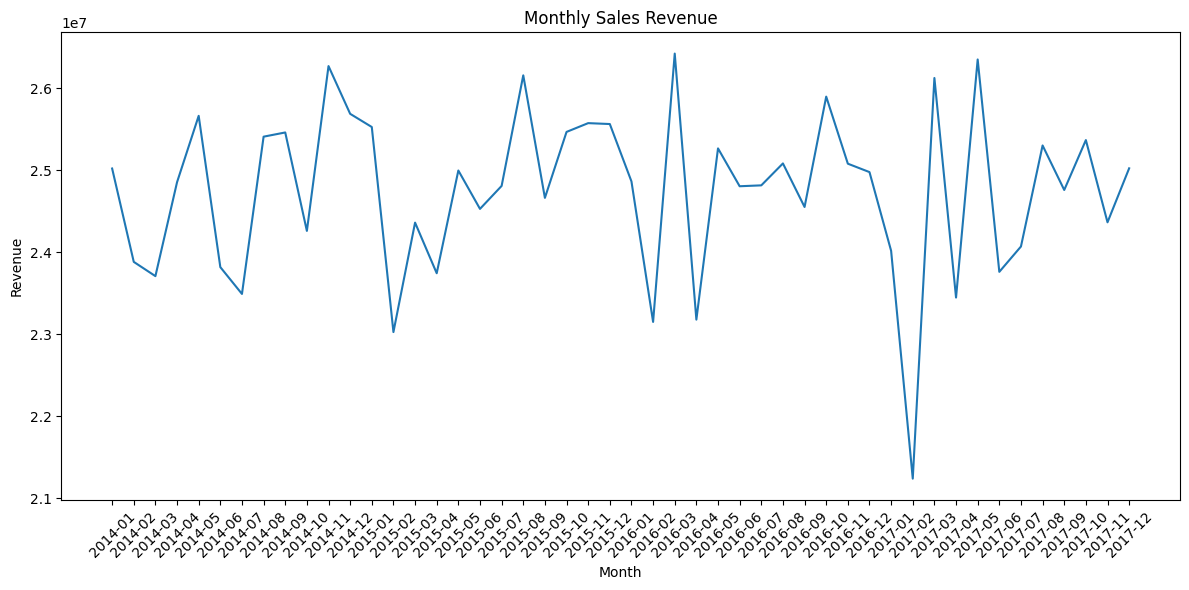

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["year_month"], monthly_sales["revenue"])
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Sales Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### **Overall Monthly Sales Seasonality**

/tmp/ipython-input-714177934.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["order_date"] = pd.to_datetime(df["order_date"])
/tmp/ipython-input-714177934.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["month"] = df["order_date"].dt.month
/tmp/ipython-input-714177934.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

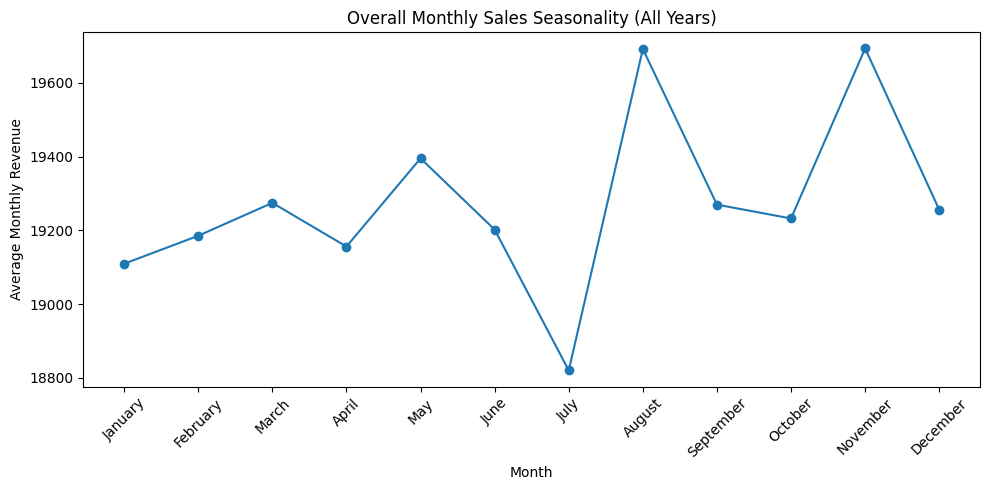

In [ ]:
# Ensure datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Extract month number and month name
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()

# Aggregate sales across ALL years by month
monthly_seasonality = (
    df.groupby(["month", "month_name"])["revenue"]
      .mean()   # mean shows typical seasonality
      .reset_index()
      .sort_values("month")
)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_seasonality["month_name"],
    monthly_seasonality["revenue"],
    marker="o"
)

plt.title("Overall Monthly Sales Seasonality (All Years)")
plt.xlabel("Month")
plt.ylabel("Average Monthly Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### **Top 10 products by revenue**


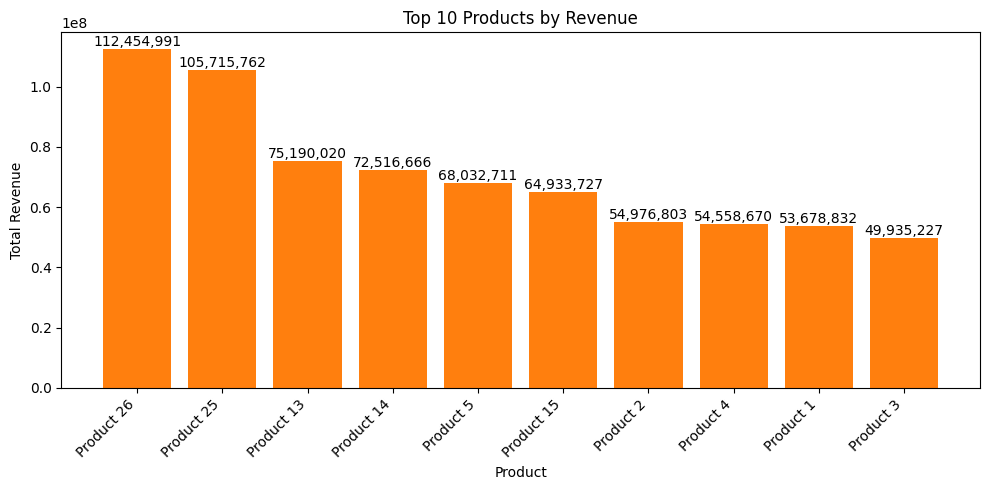

In [ ]:
# Top 10 products by revenue
top_10_products = (
    df.groupby("product_name")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_10_products
plt.figure(figsize=(10, 5))
bars = plt.bar(
    top_10_products["product_name"],
    top_10_products["revenue"]
)
plt.bar(top_10_products["product_name"], top_10_products["revenue"])
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.title("Top 10 Products by Revenue")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### **Bottom products by revenue**


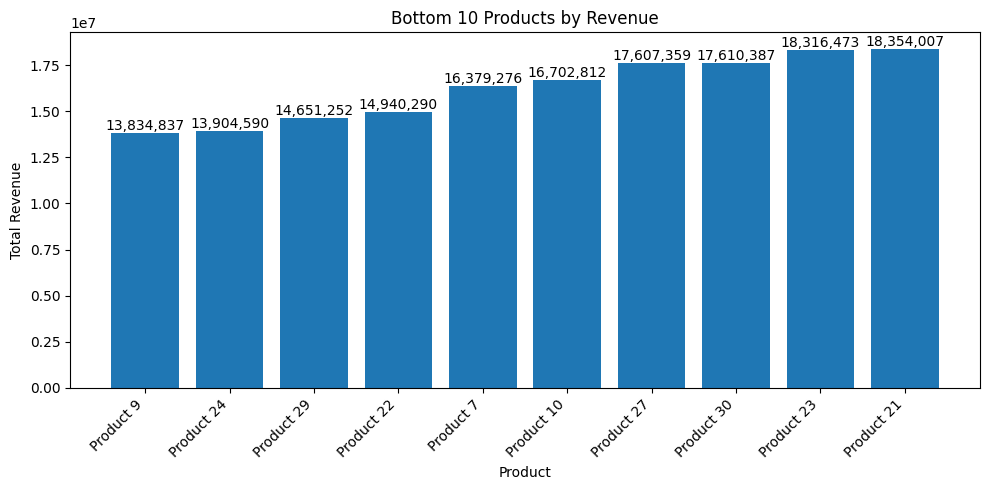

In [ ]:
bottom_10_products = (
    df.groupby("product_name")["revenue"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    bottom_10_products["product_name"],
    bottom_10_products["revenue"]
)

plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.title("Bottom 10 Products by Revenue")
plt.xticks(rotation=45, ha="right")

# Add labels on each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


#### **Sales By Channel**

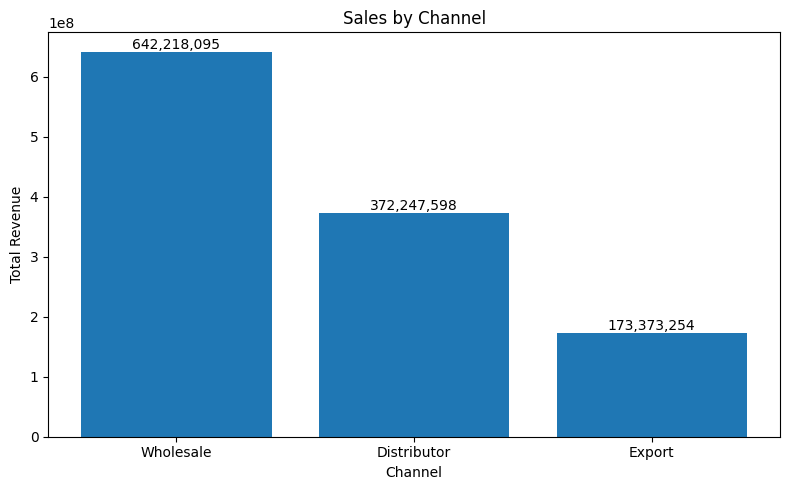

In [ ]:

# Aggregate sales by channel
sales_by_channel = (
    df.groupby("channel")["revenue"]
      .sum()
      .reset_index()
      .sort_values("revenue", ascending=False)
)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(
    sales_by_channel["channel"],
    sales_by_channel["revenue"]
)

plt.xlabel("Channel")
plt.ylabel("Total Revenue")
plt.title("Sales by Channel")

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


#### **percentages Calculation**


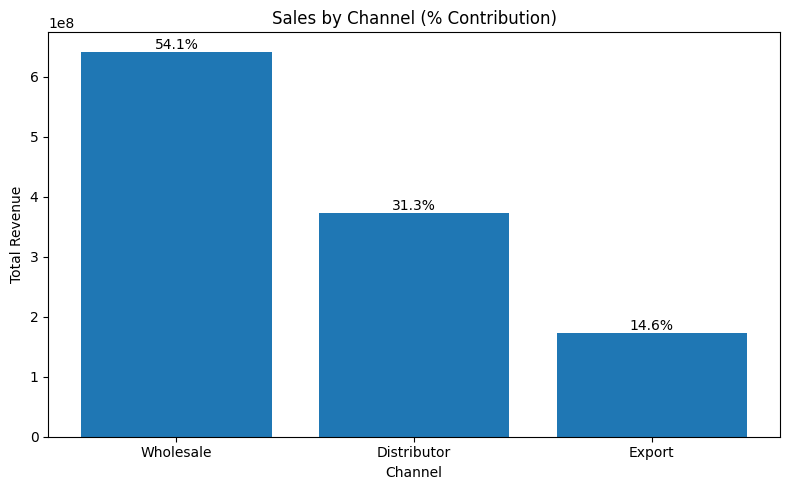

In [ ]:
total_revenue = sales_by_channel["revenue"].sum()
sales_by_channel["percentage"] = (
    sales_by_channel["revenue"] / total_revenue * 100
)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(
    sales_by_channel["channel"],
    sales_by_channel["revenue"]
)

plt.xlabel("Channel")
plt.ylabel("Total Revenue")
plt.title("Sales by Channel (% Contribution)")

# Add percentage labels
for bar, pct in zip(bars, sales_by_channel["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

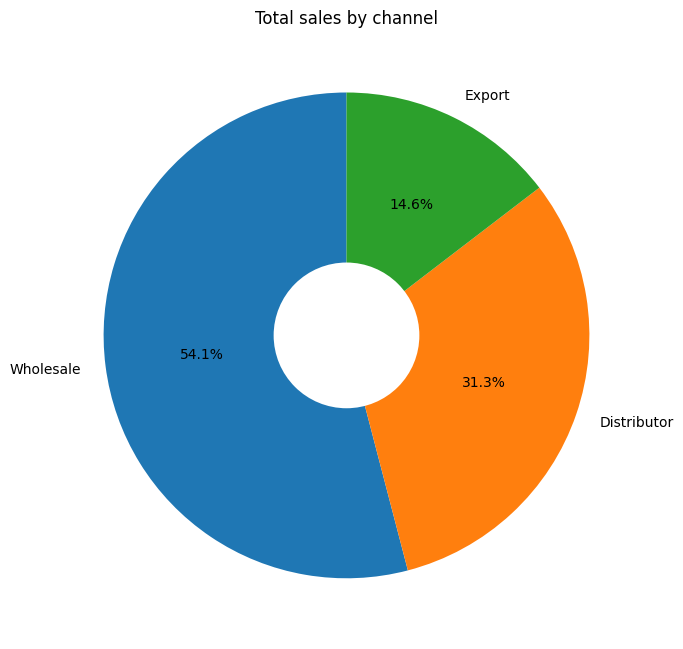

In [ ]:
sales_by_channel["percentage"] = (
    sales_by_channel["revenue"] /
    sales_by_channel["revenue"].sum() * 100
)

# Plot donut chart
plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    sales_by_channel["revenue"],
    labels=sales_by_channel["channel"],
    autopct="%1.1f%%",
    startangle=90
)

# Draw center circle to make it a donut
centre_circle = plt.Circle((0, 0), 0.30, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Total sales by channel")
plt.tight_layout()
plt.show()


#### **Average order value distribution**


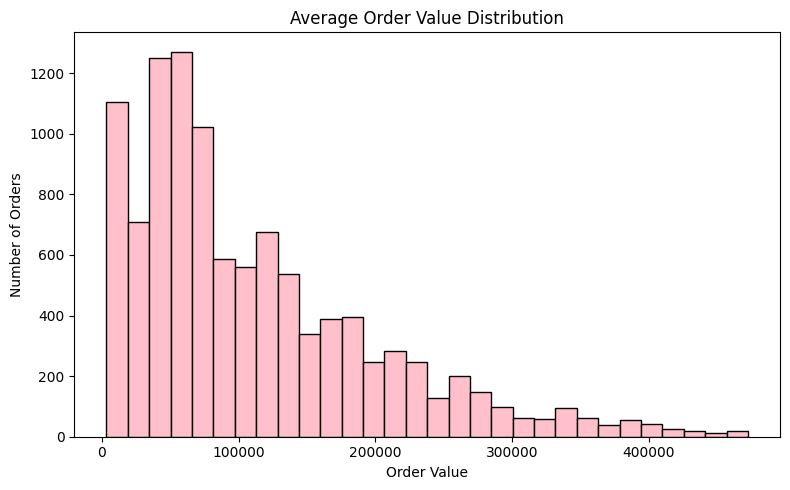

In [ ]:
order_values = (
    df.groupby('order_number')['revenue']
    .sum()
    .reset_index(name='order_value')
)

plt.figure(figsize=(8, 5))
plt.hist(order_values["order_value"],
         bins=30,
         color='pink',
         edgecolor='black')

plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.title("Average Order Value Distribution")

plt.tight_layout()
plt.show()


#### **Unit Price Distribution**


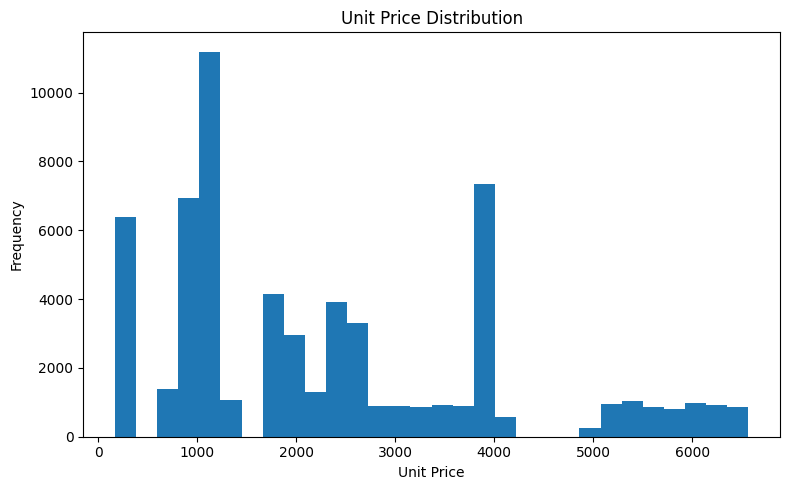

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["unit_price"], bins=30)

plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Unit Price Distribution")

plt.tight_layout()
plt.show()


In [ ]:
df.head(5)

,order_number,order_date,customer_name,channel,unit_price,order_quantity,revenue,cost,product_name,state,...,lat,lon,county,budget,total_cost,profit,profit margin %,year_month,month,month_name
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,2499.1,6,14994.6,1824.343,Product 27,GA,...,32.08354,-81.09983,Chatham County,NaN,10946.058,13170.257,87.833333,2014-01,1,January
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,2351.7,11,25868.7,1269.918,Product 20,IN,...,39.61366,-86.10665,Johnson County,NaN,13969.098,24598.782,95.090909,2014-01,1,January
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,978.2,6,5869.2,684.740,Product 26,CA,...,37.66243,-121.87468,Alameda County,NaN,4108.440,5184.460,88.333333,2014-01,1,January
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,2338.3,7,16368.1,1028.852,Product 7,IN,...,39.16533,-86.52639,Monroe County,NaN,7201.964,15339.248,93.714286,2014-01,1,January
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,2291.4,8,18331.2,1260.270,Product 8,CT,...,41.77524,-72.52443,Hartford County,NaN,10082.160,17070.930,93.125000,2014-01,1,January


#### **Unit Price Distribution per Product**


/tmp/ipython-input-813641536.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


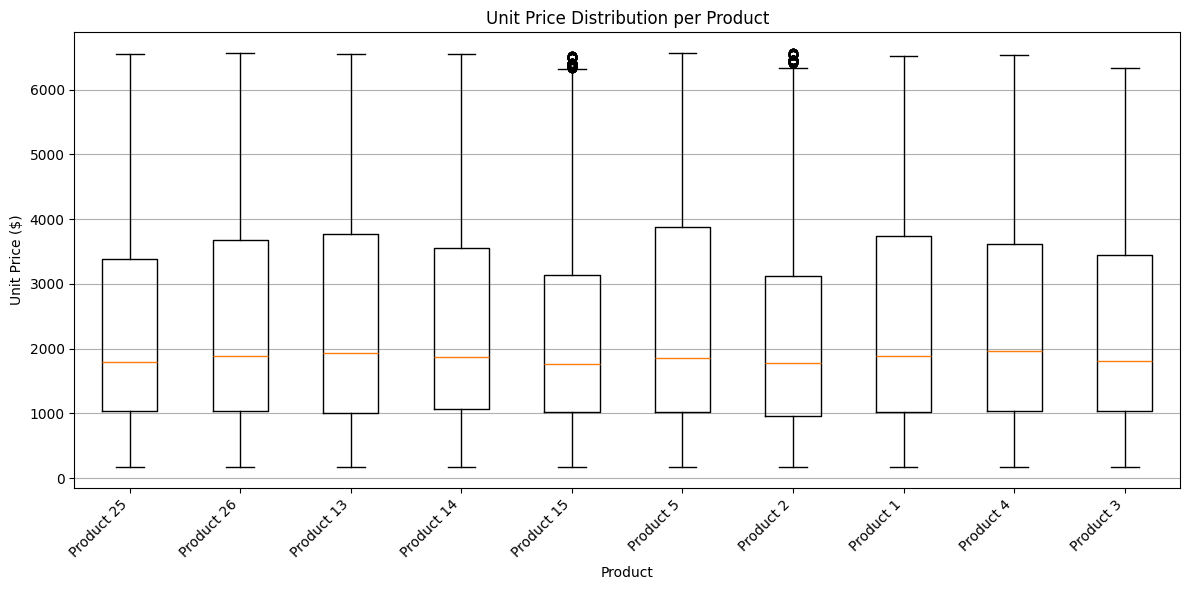

In [ ]:
unit_price_dist = (
    df.groupby("product_name")["unit_price"]
      .agg(
          count="count",
          min_price="min",
            q1=lambda x: x.quantile(0.25),
          median="median",
          mean="mean",
          q3=lambda x: x.quantile(0.75),
          max_price="max",
          std="std"
      )
      .reset_index()
)

unit_price_dist
import matplotlib.pyplot as plt

# Select top N products by volume to keep chart readable
top_products = (
    df["product_name"]
        .value_counts()
      .head(10)
      .index
)

filtered_df = df[df["product_name"].isin(top_products)]

plt.figure(figsize=(12, 6))
plt.boxplot(
    [filtered_df[filtered_df["product_name"] == p]["unit_price"]
     for p in top_products],
    labels=top_products
)

plt.xlabel("Product")
plt.ylabel("Unit Price ($)")
plt.title("Unit Price Distribution per Product")
plt.xticks(rotation=45, ha="right")
plt.grid(True,axis='y')
plt.tight_layout()
plt.show()


#### **Top states by revenue and Order Count**


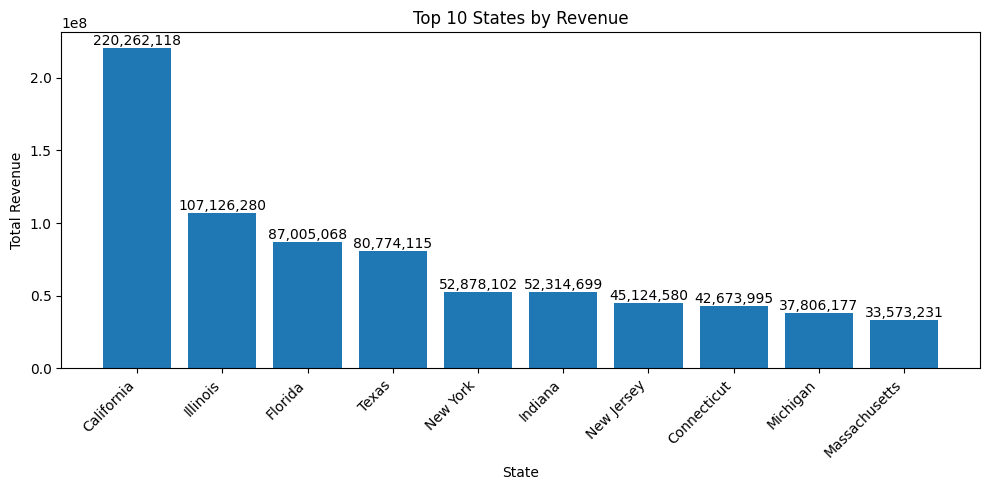

In [ ]:
top_10_states = (
    df.groupby("state_name")
      .agg(
          total_revenue=("revenue", "sum"),
          order_count=("order_number", "nunique")
      )
      .reset_index()
      .sort_values("total_revenue", ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    top_10_states["state_name"],
    top_10_states["total_revenue"]
)

plt.xlabel("State")
plt.ylabel("Total Revenue")
plt.title("Top 10 States by Revenue")
plt.xticks(rotation=45, ha="right")

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


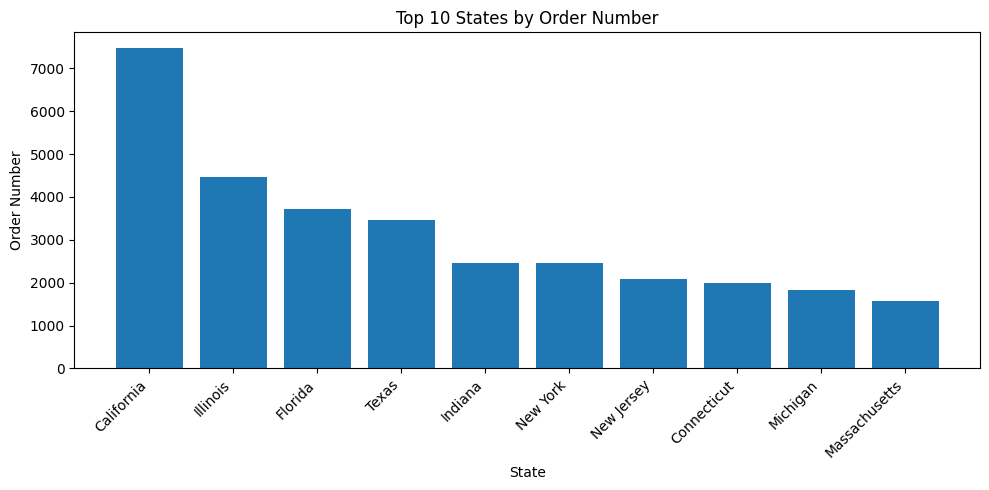

In [ ]:
top_10_states_orders = (
    df.groupby("state_name")["order_number"]
      .nunique()
      .reset_index(name="order_count")
      .sort_values("order_count", ascending=False)
      .head(10)
)
plt.figure(figsize=(10, 5))
bars = plt.bar(
    top_10_states_orders["state_name"],
    top_10_states_orders["order_count"]
)

plt.xlabel("State")
plt.ylabel("Order Number")
plt.title("Top 10 States by Order Number")
plt.xticks(rotation=45, ha="right")


plt.tight_layout()
plt.show()

#### **Average Profit Margin by channel**


/tmp/ipython-input-4127130906.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["profit"].sum() / x["revenue"].sum()) * 100)


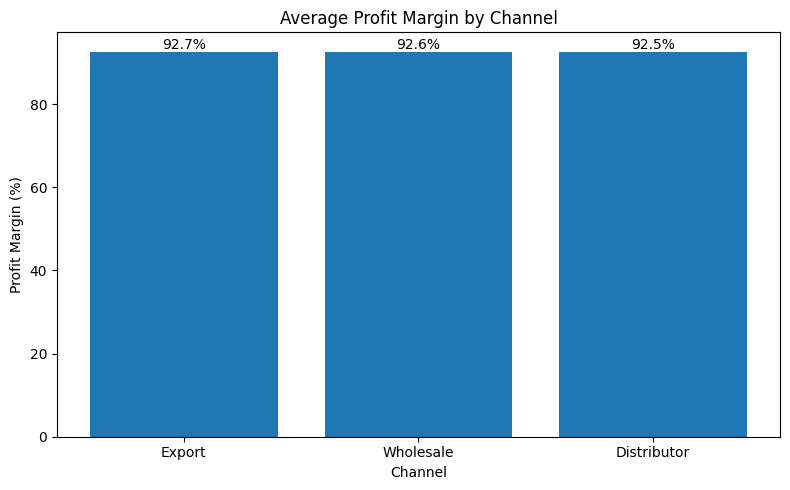

In [ ]:
# Average Profit Margin by channel
avg_profit_margin_by_channel = (
    df.groupby("channel")
      .apply(lambda x: (x["profit"].sum() / x["revenue"].sum()) * 100)
      .reset_index(name="avg_profit_margin_%")
      .sort_values("avg_profit_margin_%", ascending=False)
)

avg_profit_margin_by_channel
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_profit_margin_by_channel["channel"],
    avg_profit_margin_by_channel["avg_profit_margin_%"]
)

plt.xlabel("Channel")
plt.ylabel("Profit Margin (%)")
plt.title("Average Profit Margin by Channel")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


#### **Top Customers By Revenue**

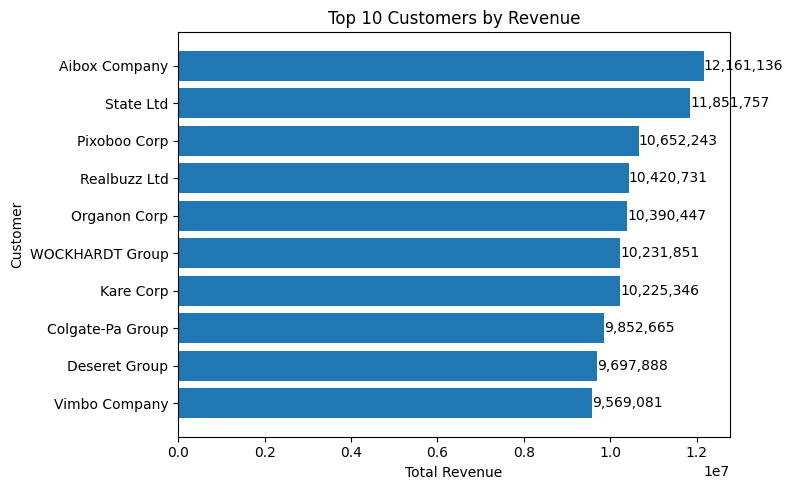

In [ ]:
top_10_customers = (
    df.groupby("customer_name")["revenue"]
      .sum()
      .reset_index()
      .sort_values("revenue", ascending=False)
      .head(10)
)

top_10_customers_plot = top_10_customers.sort_values("revenue", ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(
    top_10_customers_plot["customer_name"],
    top_10_customers_plot["revenue"]
)

plt.xlabel("Total Revenue")
plt.ylabel("Customer")
plt.title("Top 10 Customers by Revenue")

# Add labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()


#### **Bottom Customers By Revenue**

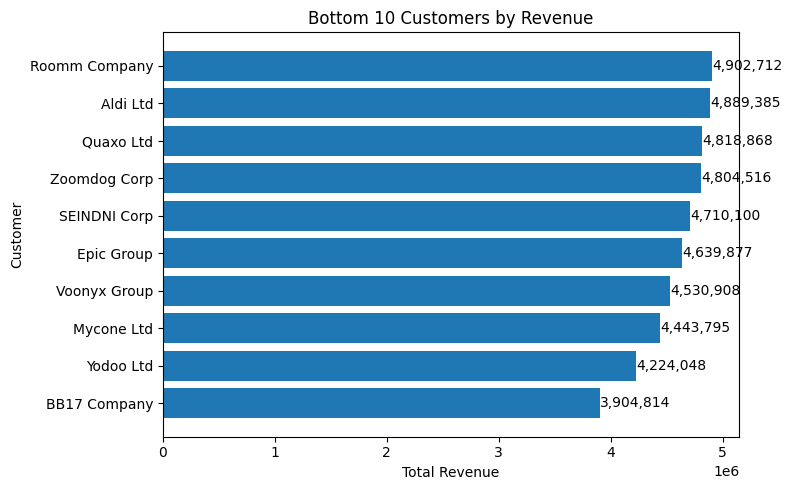

In [ ]:
bottom_10_customers = (
    df.groupby("customer_name")["revenue"]
      .sum()
      .reset_index()
      .sort_values("revenue", ascending=True)
      .head(10)
)

plt.figure(figsize=(8, 5))
bars = plt.barh(
    bottom_10_customers["customer_name"],
    bottom_10_customers["revenue"]
)

plt.xlabel("Total Revenue")
plt.ylabel("Customer")
plt.title("Bottom 10 Customers by Revenue")

# Add labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        ha="left"
    )

plt.tight_layout()
plt.show()



#### **Customer Segmentation** : Revenue VS Profit Margin

In [ ]:
# Customer Segmentation : Revenue VS Profit Margin

customer_segmentation = (
    df.groupby("customer_name")
      .agg(
          total_revenue=("revenue", "sum"),
          total_profit=("profit", "sum")
      )
      .reset_index()
)

# Profit Margin %
customer_segmentation["profit_margin_pct"] = (
    customer_segmentation["total_profit"] /
    customer_segmentation["total_revenue"]
) * 100

# Segmentation thresholding
revenue_threshold = customer_segmentation["total_revenue"].median()
margin_threshold = customer_segmentation["profit_margin_pct"].median()

# Customer Segmentation
def segment_customer(row):
    if row["total_revenue"] >= revenue_threshold and row["profit_margin_pct"] >= margin_threshold:
        return "High Revenue / High Margin (Champions)"
    elif row["total_revenue"] >= revenue_threshold and row["profit_margin_pct"] < margin_threshold:
        return "High Revenue / Low Margin (Volume Buyers)"
    elif row["total_revenue"] < revenue_threshold and row["profit_margin_pct"] >= margin_threshold:
        return "Low Revenue / High Margin (Niche)"
    else:
        return "Low Revenue / Low Margin (At Risk)"

customer_segmentation["segment"] = customer_segmentation.apply(segment_customer, axis=1)


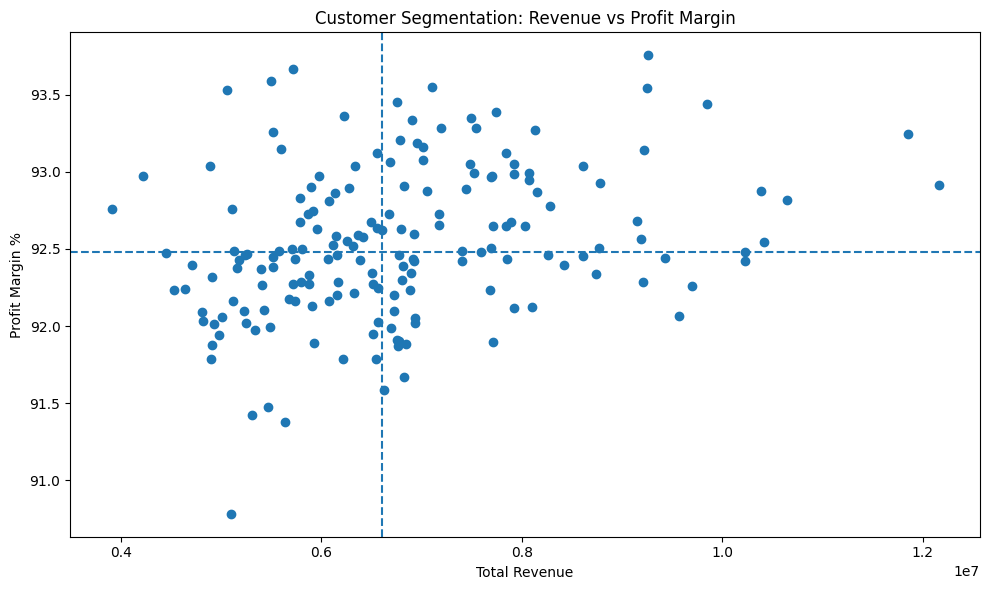

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_segmentation["total_revenue"],
    customer_segmentation["profit_margin_pct"]
)

# Threshold lines
plt.axvline(revenue_threshold, linestyle="--")
plt.axhline(margin_threshold, linestyle="--")

plt.xlabel("Total Revenue")
plt.ylabel("Profit Margin %")
plt.title("Customer Segmentation: Revenue vs Profit Margin")

plt.tight_layout()
plt.show()


In [ ]:
# Segment Summary Table
segment_summary = (
    customer_segmentation.groupby("segment")
      .agg(
          customers=("customer_name", "count"),
          revenue=("total_revenue", "sum"),
          avg_margin=("profit_margin_pct", "mean")
      )
      .reset_index()
)

segment_summary


,segment,customers,revenue,avg_margin
0,High Revenue / High Margin (Champions),54,434363881.0,92.964984
1,High Revenue / Low Margin (Volume Buyers),34,261699159.2,92.193581
2,Low Revenue / High Margin (Niche),34,197188644.7,92.851438
3,Low Revenue / Low Margin (At Risk),53,294587261.6,92.124690


#### **Correlation Matrix**

In [ ]:
cols = ["unit_price", "order_quantity", "revenue", "cost", "profit"]

corr_matrix = df[cols].corr()


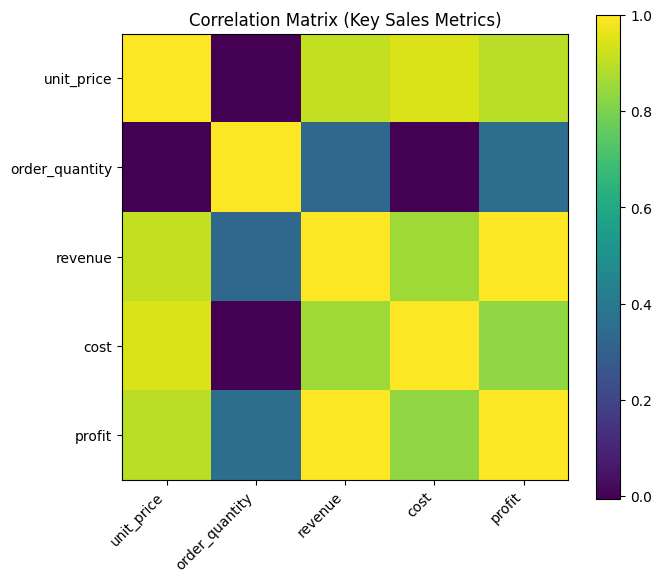

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 6))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(
    ticks=np.arange(len(cols)),
    labels=cols,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(cols)),
    labels=cols
)

plt.title("Correlation Matrix (Key Sales Metrics)")
plt.tight_layout()
plt.show()


In [ ]:
# Channel Distribution : 54% wholesale, 31% distribution, 15% exports
# Monthly Revenue Cycle : May peak at x$M
# Top 10 products(revenue)
# bottom 10 products(revenue)

In [ ]:
df.to_csv('final.csv')

In [ ]:
df.head(5)

,order_number,order_date,customer_name,channel,unit_price,order_quantity,revenue,cost,product_name,state,...,lat,lon,county,budget,total_cost,profit,profit margin %,year_month,month,month_name
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,2499.1,6,14994.6,1824.343,Product 27,GA,...,32.08354,-81.09983,Chatham County,NaN,10946.058,13170.257,87.833333,2014-01,1,January
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,2351.7,11,25868.7,1269.918,Product 20,IN,...,39.61366,-86.10665,Johnson County,NaN,13969.098,24598.782,95.090909,2014-01,1,January
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,978.2,6,5869.2,684.740,Product 26,CA,...,37.66243,-121.87468,Alameda County,NaN,4108.440,5184.460,88.333333,2014-01,1,January
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,2338.3,7,16368.1,1028.852,Product 7,IN,...,39.16533,-86.52639,Monroe County,NaN,7201.964,15339.248,93.714286,2014-01,1,January
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,2291.4,8,18331.2,1260.270,Product 8,CT,...,41.77524,-72.52443,Hartford County,NaN,10082.160,17070.930,93.125000,2014-01,1,January
